<div
     style="padding: 20px;
            color: white;
            font-size: 240%;
            text-align: center;
            border-radius: 5px;
            background-color: #023c66;
            overflow: hidden;
            font-weight: 700;
            border: 5px solid #F28C28;">
    EDA Worksheet 2 — Fix, Encode, Transform, and Prepare
</div>

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module:** Exploratory Data Analysis (EDA)  
**Focus:** Missing values, indicators, imputation, unusual values, transformations, encoding, leakage, and model-ready data

## Learning Goals

1. Use EDA findings to make data-preparation decisions.
2. Treat structurally invalid zeros as missing when appropriate.
3. Calculate missing-value fractions and create missingness indicators before imputation.
4. Compare mean, median, KNN, and categorical imputation.
5. Investigate unusual observations before deleting them.
6. Transform highly skewed numeric variables.
7. Compare dummy, one-hot, label, and mixed encoding strategies.
8. Remove variables inappropriate for the intended prediction problem.
9. Recognize preprocessing leakage and target leakage.
10. Understand how EDA concepts extend to dates, text, and images.
11. Produce and save a documented model-ready dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
print("Ready!")

Ready!


---

# 1. Continue With the Same Veterans Dataset


We also load the raw version for the encoding section.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA591/refs/heads/main/data/veterans_eda.csv')
df.head()

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
0,0,2,4,1,3,17.0,13.50,9.25,17.00,21,66,8,17,26,3,8,13,A,0,0,NaN,F,U,0,0,0
1,0,1,8,0,3,20.0,20.00,15.88,NaN,26,92,14,35,79,5,5,24,A,0,23,67.0,F,U,186800,85,0
2,1,6,41,3,20,6.0,5.17,3.73,5.00,18,111,12,23,51,5,11,22,S,1,0,NaN,M,U,87600,36,38750
3,1,3,12,3,8,10.0,8.67,8.50,8.67,9,93,14,22,44,2,6,16,E,1,0,NaN,M,U,139200,27,38942
4,0,1,1,1,1,20.0,20.00,20.00,20.00,21,21,10,15,13,4,7,6,F,0,35,53.0,M,U,168100,37,71509


---

# 2. Domain-Informed Missing Values

Sometimes a recorded value is technically present but does not make sense.

In the earlier notes, zeros for:

- `DemMedHomeValue`
- `DemMedIncome`

were treated as missing values.

This is an important EDA lesson:

> **Missingness is sometimes discovered through domain logic, not just `NaN`.**

In [3]:
## missing values
df.isna().sum()

TARGET_B               0
GiftCnt36              0
GiftCntAll             0
GiftCntCard36          0
GiftCntCardAll         0
GiftAvgLast            0
GiftAvg36              0
GiftAvgAll             0
GiftAvgCard36       1780
GiftTimeLast           0
GiftTimeFirst          0
PromCnt12              0
PromCnt36              0
PromCntAll             0
PromCntCard12          0
PromCntCard36          0
PromCntCardAll         0
StatusCat96NK          0
StatusCatStarAll       0
DemCluster             0
DemAge              2407
DemGender              0
DemHomeOwner           0
DemMedHomeValue        0
DemPctVeterans         0
DemMedIncome           0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET_B,9686.0,0.500000,0.500026,0.00,0.00,0.50,1.0,1.0
GiftCnt36,9686.0,3.205451,2.133421,0.00,2.00,3.00,4.0,16.0
GiftCntAll,9686.0,10.507640,8.993401,1.00,4.00,8.00,15.0,91.0
GiftCntCard36,9686.0,1.856597,1.595419,0.00,1.00,1.00,3.0,9.0
GiftCntCardAll,9686.0,5.582490,4.736894,0.00,2.00,4.00,8.0,41.0
GiftAvgLast,9686.0,16.017739,12.041805,0.00,10.00,15.00,20.0,450.0
GiftAvg36,9686.0,14.876203,10.057007,0.00,9.60,13.50,18.5,260.0
GiftAvgAll,9686.0,12.489325,9.209297,1.50,7.75,10.71,15.0,450.0
GiftAvgCard36,7906.0,14.224431,10.022710,1.33,8.67,12.50,18.0,260.0
GiftTimeLast,9686.0,18.002168,4.073549,4.00,16.00,18.00,20.0,27.0


In [6]:
# TODO: inspect the number of zeros first
### Unusual values might need to be replaced with missing or NAs
### Age: -99999 -----------------------NaN
### Income: 0 -------------------------NaN (survey data: might mean the user does not want to report income)

print("Zero home values:", (df["DemMedHomeValue"] == 0).sum())
print("Zero incomes:", (df["DemMedIncome"] == 0).sum())

# TODO: convert those zeros to NaN
df["DemMedHomeValue"] = df["DemMedHomeValue"].replace(0, np.nan)
df["DemMedIncome"] = df["DemMedIncome"].replace(0, np.nan)

Zero home values: 103
Zero incomes: 2357


In [7]:
print("Zero home values:", (df["DemMedHomeValue"] == 0).sum())
print("Zero incomes:", (df["DemMedIncome"] == 0).sum())

Zero home values: 0
Zero incomes: 0


---

# 3. Quantify Missingness

The earlier notebooks emphasized **fraction missing**, not just counts.

A rule such as "consider removing variables with >50% missing" can be a useful screening rule—but it is not automatic. Business value matters too.

In [8]:
# TODO
missing_count = df.isna().sum()               ## count of missing values per var
missing_fraction = df.isna().sum() / len(df)  ## fraction of missing values per var

missing_table = pd.DataFrame({
    "MissingCount": missing_count,
    "MissingFraction": missing_fraction
})

missing_table = missing_table[
    missing_table["MissingCount"] > 0
].sort_values("MissingFraction", ascending=False)

missing_table

,MissingCount,MissingFraction
DemAge,2407,0.248503
DemMedIncome,2357,0.243341
GiftAvgCard36,1780,0.183770
DemMedHomeValue,103,0.010634


## Practice 3A — Plot missing fractions

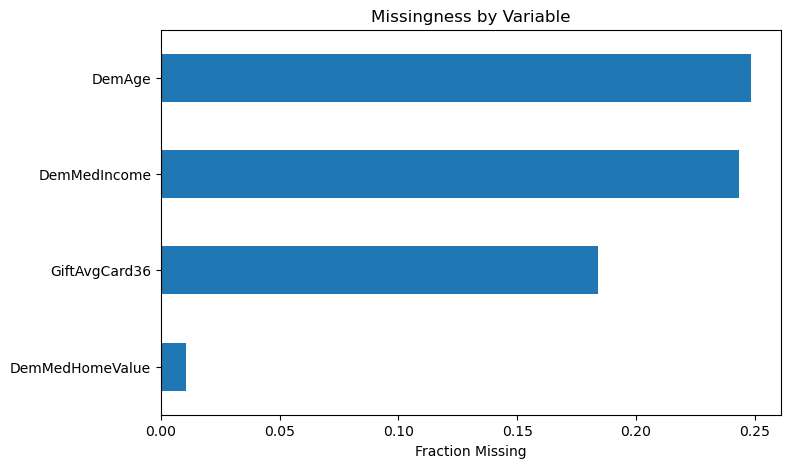

In [9]:
# TODO
missing_table["MissingFraction"].sort_values().plot(
    kind="barh",
     figsize=(8,5)
)
plt.xlabel("Fraction Missing")
plt.title("Missingness by Variable")
plt.show()

### Decision

Would you automatically delete every variable with >50% missing? What else should be considered?

**Your response here:**  
-

---

# 4. Missing-Value Indicators — Create Them BEFORE Imputation

A missing indicator can preserve information about **which observations were originally missing**.

The earlier notebooks used `MissingIndicator` and retained an indicator for variables with substantial missingness.

In [12]:
vars_with_missing = missing_table.index.tolist()
vars_with_missing

indicator_names = [f"{c}_Missing" for c in vars_with_missing]
indicator_names

['DemAge_Missing',
 'DemMedIncome_Missing',
 'GiftAvgCard36_Missing',
 'DemMedHomeValue_Missing']

In [15]:
## module that does missing indicators
from sklearn.impute import MissingIndicator

## check the variable names for vars with missing values
vars_with_missing = missing_table.index.tolist()
## create the missing indicators by appending a "_missing" to each var with missing
indicator_names = [f"{c}_Missing" for c in vars_with_missing]

# TODO
## instance
indicator = MissingIndicator(features="all")
## fit transform
indicator_matrix = indicator.fit_transform(df[vars_with_missing])

## append these variables to the data set (df)
df[indicator_names] = indicator_matrix.astype(int)
df.head()

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome,DemAge_Missing,DemMedIncome_Missing,GiftAvgCard36_Missing,DemMedHomeValue_Missing
0,0,2,4,1,3,17.0,13.50,9.25,17.00,21,66,8,17,26,3,8,13,A,0,0,NaN,F,U,NaN,0,NaN,1,1,0,1
1,0,1,8,0,3,20.0,20.00,15.88,NaN,26,92,14,35,79,5,5,24,A,0,23,67.0,F,U,186800.0,85,NaN,0,1,1,0
2,1,6,41,3,20,6.0,5.17,3.73,5.00,18,111,12,23,51,5,11,22,S,1,0,NaN,M,U,87600.0,36,38750.0,1,0,0,0
3,1,3,12,3,8,10.0,8.67,8.50,8.67,9,93,14,22,44,2,6,16,E,1,0,NaN,M,U,139200.0,27,38942.0,1,0,0,0
4,0,1,1,1,1,20.0,20.00,20.00,20.00,21,21,10,15,13,4,7,6,F,0,35,53.0,M,U,168100.0,37,71509.0,0,0,0,0


### Easier one-variable version

For one variable:

```python
df["DemMedIncome_Missing"] = df["DemMedIncome"].isna().astype(int)
```

In [16]:
# TODO
# df["DemMedIncome_Missing"] = None

df[["DemMedIncome", "DemMedIncome_Missing"]].head(10)

,DemMedIncome,DemMedIncome_Missing
0,NaN,1
1,NaN,1
2,38750.0,0
3,38942.0,0
4,71509.0,0
5,92514.0,0
6,72868.0,0
7,NaN,1
8,NaN,1
9,NaN,1


### Question

Why must the indicator be created **before** the missing values are filled?

**Your response here:**  
-

---

# 5. Numeric Imputation

The earlier materials demonstrated:

- mean imputation
- median imputation
- K-nearest-neighbor imputation

The best choice depends on the variable and business context.

## Practice 5A — Compare mean and median

In [17]:
for col in ["DemMedHomeValue", "DemMedIncome", "DemAge", "GiftAvgCard36"]:
    if col in df.columns:
        print(
            col,
            "mean =", round(df[col].mean(), 2),
            "median =", round(df[col].median(), 2),
            "missing =", df[col].isna().sum()
        )

DemMedHomeValue mean = 112179.2 median = 77700.0 missing = 103
DemMedIncome mean = 53513.46 median = 48699.0 missing = 2357
DemAge mean = 59.15 median = 60.0 missing = 2407
GiftAvgCard36 mean = 14.22 median = 12.5 missing = 1780


### Decision

Which variables look skewed enough that you would prefer a median over a mean?

**Your response here:**  
-

## Practice 5B — Mean and median imputation

In [18]:
# TODO
# Example choices: (median because of skewness)
df["DemMedHomeValue"] = df["DemMedHomeValue"].fillna(df["DemMedHomeValue"].median())
df["DemMedIncome"] = df["DemMedIncome"].fillna(df["DemMedIncome"].median())

## Practice 5C — KNN imputation

KNN imputation uses similar observations to estimate missing values.

The previous notebook used `DemAge` and `GiftAvgCard36`.

In [19]:
## Model imputation
## k-Nearest Neighbor Imputation is used to predict the missing values with th k-closest variables (in terms of other predictors)
from sklearn.impute import KNNImputer

# TODO
## let;s use the two closest neighbor observations and average the values so that we can impute with those
imputer = KNNImputer(n_neighbors=2) 

df[["GiftAvgCard36", "DemAge"]] = imputer.fit_transform(
     df[["GiftAvgCard36", "DemAge"]]
)

### Important note

KNN uses distance. When variables are on very different scales, scaling can influence which observations count as "nearest."

That is an important consideration when using KNN imputation in a real project.

---

# 6. Categorical Imputation

One approach is to create an explicit category such as `"Missing"`.

Scikit-learn also provides `SimpleImputer`.

In [ ]:
## You can use the .fillna("unknown") or .fillna("missing") 

In [ ]:
## to impute all missing categorical at the same time
from sklearn.impute import SimpleImputer

# Example
categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Missing"
)

print(categorical_imputer)

## categorical_imputer.fit_transform(data)

SimpleImputer(fill_value='Missing', strategy='constant')


## Practice 6A — Why could `"Missing"` be more informative than using the most common category?

**Your response here:**  
-

---

# 7. Unusual and Impossible Values

The previous notes emphasized two different situations:

### Impossible / suspicious values
Example: an age such as 160.

One reasonable approach is:

1. set it to missing
2. impute it using an appropriate method

### Extreme but possible values
Large donations may be real.

Do **not** delete a value simply because a boxplot labels it as an outlier.

## Practice 7A — Search for impossible ages

In [21]:
# TODO
suspicious_age = df[df["DemAge"] > 110]
suspicious_age

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome,DemAge_Missing,DemMedIncome_Missing,GiftAvgCard36_Missing,DemMedHomeValue_Missing


## Practice 7B — Inspect unusually large gift values

In [23]:
gift_cols[:-1]

['GiftCnt36',
 'GiftCntAll',
 'GiftCntCard36',
 'GiftCntCardAll',
 'GiftAvgLast',
 'GiftAvg36',
 'GiftAvgAll',
 'GiftAvgCard36',
 'GiftTimeLast',
 'GiftTimeFirst']

In [ ]:
gift_cols = [c for c in df.columns if c.startswith("Gift")]

## let's get rid of GiftAvgCard36_Missing (indicator variable)
gift_cols = gift_cols[:-1]

df[gift_cols].describe().T

## suggestion to transform all gift cols to logs

,count,mean,std,min,25%,50%,75%,max
GiftCnt36,9686.0,3.205451,2.133421,0.00,2.00,3.00,4.0,16.0
GiftCntAll,9686.0,10.507640,8.993401,1.00,4.00,8.00,15.0,91.0
GiftCntCard36,9686.0,1.856597,1.595419,0.00,1.00,1.00,3.0,9.0
GiftCntCardAll,9686.0,5.582490,4.736894,0.00,2.00,4.00,8.0,41.0
GiftAvgLast,9686.0,16.017739,12.041805,0.00,10.00,15.00,20.0,450.0
GiftAvg36,9686.0,14.876203,10.057007,0.00,9.60,13.50,18.5,260.0
GiftAvgAll,9686.0,12.489325,9.209297,1.50,7.75,10.71,15.0,450.0
GiftAvgCard36,9686.0,14.146471,9.660333,1.33,9.00,13.00,17.0,260.0
GiftTimeLast,9686.0,18.002168,4.073549,4.00,16.00,18.00,20.0,27.0
GiftTimeFirst,9686.0,71.100351,37.691984,15.00,36.00,68.00,105.0,260.0


In [25]:
# Examine rows with large GiftAvgAll
df[df["GiftAvgAll"] > 250]

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome,DemAge_Missing,DemMedIncome_Missing,GiftAvgCard36_Missing,DemMedHomeValue_Missing
7389,1,0,1,0,0,450.0,0.0,450.0,14.224431,23,23,25,25,38,6,6,8,N,0,24,59.150845,F,H,206700.0,24,65740.0,1,0,1,0


In [28]:
## delete obs with gift avg greater than 250
df = df[df["GiftAvgAll"] < 250]

### Decision

The previous notebook investigated several rows with unusually large gift values.

Would you:
- keep them,
- delete them,
- cap/winsorize them,
- or investigate further?

Explain your decision before changing anything.

**Your response here:**  
-

---

# 8. Transform Right-Skewed Variables

The earlier materials used a log transformation for the `Gift...` variables.

Because zeros may be present:

$$
z = \log(x + 0.1)
$$

## Practice 8A — Compare original and transformed distributions

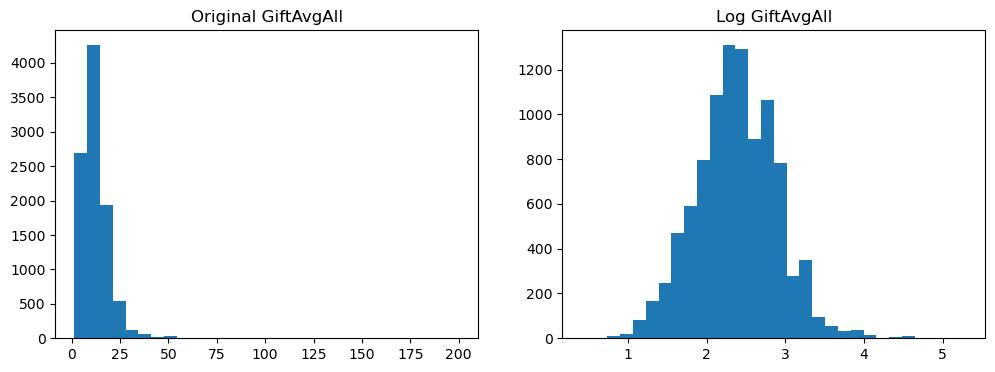

In [29]:
x = df["GiftAvgAll"].fillna(0)

# TODO
log_x = np.log(x + 0.01)

# TODO
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(x, bins=30)
ax[0].set_title("Original GiftAvgAll")
ax[1].hist(log_x, bins=30)
ax[1].set_title("Log GiftAvgAll")
plt.show()

### Interpretation

1. What changed about the shape?
2. Did transformation delete extreme observations?
3. Why can transformation be preferable to simply deleting legitimate large values?

**Your response here:**  
1.  
2.  
3.

## Optional — Transform many gift variables

In [30]:
from sklearn.preprocessing import FunctionTransformer

def log_transform(x):
    return np.log(x + 0.1)

transformer = FunctionTransformer(log_transform)

# Example:
df[gift_cols] = transformer.fit_transform(df[gift_cols])
df[gift_cols]

C:\Users\martinwg\AppData\Local\Temp\ipykernel_18752\1841004270.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[gift_cols] = transformer.fit_transform(df[gift_cols])


,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst
0,0.741937,1.410987,0.095310,1.131402,2.839078,2.610070,2.235376,2.839078,3.049273,4.191169
1,0.095310,2.091864,-2.302585,1.131402,3.000720,3.000720,2.771338,2.778819,3.261935,4.522875
2,1.808289,3.716008,1.131402,3.000720,1.808289,1.662030,1.342865,1.629241,2.895912,4.710431
3,1.131402,2.493205,1.131402,2.091864,2.312535,2.171337,2.151762,2.171337,2.208274,4.533674
4,0.095310,0.095310,0.095310,0.095310,3.000720,3.000720,3.000720,3.000720,3.049273,3.049273
...,...,...,...,...,...,...,...,...,...,...
9681,0.741937,0.741937,0.741937,0.741937,2.312535,2.714695,2.714695,2.714695,2.839078,3.182212
9682,1.131402,1.410987,0.095310,0.095310,2.312535,2.597491,2.451005,2.312535,3.222868,3.468856
9683,2.208274,2.646175,1.629241,1.960095,2.312535,2.183802,2.055405,2.186051,2.714695,4.009150
9684,0.741937,1.960095,-2.302585,0.095310,1.629241,2.533697,2.018895,2.661967,1.808289,4.027136


---

# 9. Encoding Categorical Variables

For modeling, categorical information must usually be represented numerically.

We compare

- **dummy encoding** — omit one reference level
- **one-hot encoding** — retain all levels
- **label encoding**
- **mixed encoding**

Before encoding, always ask:

1. Does the variable belong in the model?
2. How many levels does it have?
3. Does the category have a true order?

## Practice 9B — Dummy encoding

Encode `StatusCat96NK`, `DemGender`, and `DemHomeOwner` using `drop_first=True`.

Leave `DemCluster` alone because it has many levels.

In [31]:
# TODO
## remember we do not want to encode df.DemCluster b/c of too many levels

modeling_df = pd.get_dummies(df, columns = ['StatusCat96NK', 'DemGender', 'DemHomeOwner'], drop_first=True, dtype = int)
modeling_df

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCatStarAll,DemCluster,DemAge,DemMedHomeValue,DemPctVeterans,DemMedIncome,DemAge_Missing,DemMedIncome_Missing,GiftAvgCard36_Missing,DemMedHomeValue_Missing,StatusCat96NK_E,StatusCat96NK_F,StatusCat96NK_L,StatusCat96NK_N,StatusCat96NK_S,DemGender_M,DemGender_U,DemHomeOwner_U
0,0,0.741937,1.410987,0.095310,1.131402,2.839078,2.610070,2.235376,2.839078,3.049273,4.191169,8,17,26,3,8,13,0,0,59.000000,77700.0,0,48699.0,1,1,0,1,0,0,0,0,0,0,0,1
1,0,0.095310,2.091864,-2.302585,1.131402,3.000720,3.000720,2.771338,2.778819,3.261935,4.522875,14,35,79,5,5,24,0,23,67.000000,186800.0,85,48699.0,0,1,1,0,0,0,0,0,0,0,0,1
2,1,1.808289,3.716008,1.131402,3.000720,1.808289,1.662030,1.342865,1.629241,2.895912,4.710431,12,23,51,5,11,22,1,0,54.500000,87600.0,36,38750.0,1,0,0,0,0,0,0,0,1,1,0,1
3,1,1.131402,2.493205,1.131402,2.091864,2.312535,2.171337,2.151762,2.171337,2.208274,4.533674,14,22,44,2,6,16,1,0,50.000000,139200.0,27,38942.0,1,0,0,0,1,0,0,0,0,1,0,1
4,0,0.095310,0.095310,0.095310,0.095310,3.000720,3.000720,3.000720,3.000720,3.049273,3.049273,10,15,13,4,7,6,0,35,53.000000,168100.0,37,71509.0,0,0,0,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9681,1,0.741937,0.741937,0.741937,0.741937,2.312535,2.714695,2.714695,2.714695,2.839078,3.182212,19,29,27,8,12,11,0,44,47.000000,68200.0,38,45909.0,1,0,0,0,0,0,0,1,0,1,0,0
9682,0,1.131402,1.410987,0.095310,0.095310,2.312535,2.597491,2.451005,2.312535,3.222868,3.468856,11,29,29,6,15,13,0,44,63.500000,71900.0,35,50530.0,1,0,0,0,0,0,0,0,0,0,1,0
9683,1,2.208274,2.646175,1.629241,1.960095,2.312535,2.183802,2.055405,2.186051,2.714695,4.009150,13,35,46,6,17,18,1,40,71.000000,115700.0,32,48699.0,0,1,0,0,0,0,0,0,1,0,0,0
9684,0,0.741937,1.960095,-2.302585,0.095310,1.629241,2.533697,2.018895,2.661967,1.808289,4.027136,15,34,42,6,6,16,0,40,59.150845,106300.0,32,62717.0,1,0,1,0,0,0,0,0,0,1,0,0


## Practice 9C — One-hot encoding

What changes if `drop_first=False`?

In [ ]:
# TODO
df_onehot = None


### Question

Why does dummy encoding create one fewer column per categorical variable than full one-hot encoding?

**Your response here:**  
-

---

# 10. Label Encoding — Use With Care

The prior notebooks demonstrated `LabelEncoder`, but they also cautioned against using arbitrary numeric labels for unordered categories.

Example:

```python
A -> 0
E -> 1
F -> 2
S -> 3
```

A model may interpret those numbers as ordered or spaced quantities even when that interpretation is meaningless.

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Demonstration only
encoded_status = le.fit_transform(df["StatusCat96NK"])

pd.DataFrame({
    "Original": df["StatusCat96NK"].head(10),
    "Encoded": encoded_status[:10]
})

,Original,Encoded
0,A,0
1,A,0
2,S,5
3,E,1
4,F,2
5,S,5
6,A,0
7,A,0
8,A,0
9,A,0


### Practice 10A

When would an ordinal/integer encoding be more defensible than arbitrary label encoding?

**Your response here:**  
-

---

# 11. Mixed Encoding

Real projects often require different treatments for different predictors.

For example:

- dummy encode `DemGender`
- dummy encode `DemHomeOwner`
- leave `DemCluster` for later dimension reduction
- treat `StatusCat96NK` according to whether its ordering is substantively meaningful

## Practice 11A — Why is a single encoding rule for every categorical variable often inappropriate?

**Your response here:**  
-

---

# 12. Remove Variables Inappropriate for the Prediction Goal

If predicting `TARGET_B`, we should consider removing:

- `ID` — identifier
- `TARGET_D` — second outcome / unavailable if donation has not yet occurred

In [ ]:
# TODO
# modeling_df = df_dummy.drop(columns=["ID", "TARGET_D"])

# print(modeling_df.shape)

---

# 13. Data Leakage — An Important Addition

A predictor is **leaky** when it contains information that would not actually be available when the prediction is made.

Examples:

- donation amount after the campaign when predicting whether someone will donate
- an outcome-derived variable
- future information

Also remember:

> Imputation values, scalers, and feature-selection rules should eventually be learned from the **training set only**.

We will implement that rigorously when we begin modeling.

## Practice 13A — Leakage scenario

You want to predict `TARGET_B` before sending next year's solicitation.

Would you use `TARGET_D` as a predictor? Explain in business terms.

**Your response here:**  
-

---

# 14. Optional Extension — Dates

The Veterans dataset does not contain an equivalent raw date field, so this is a short transferable example rather than a change of dataset.

In [33]:
date_example = pd.DataFrame({
    "CONTACT_DATE": ["2004-01-15", "2005-08-20", "2005-11-02"]
})

date_example["CONTACT_DATE"] = pd.to_datetime(date_example["CONTACT_DATE"])

# TODO
date_example["CONTACT_MONTH"] = date_example["CONTACT_DATE"].dt.month
date_example["CONTACT_YEAR"] = date_example["CONTACT_DATE"].dt.year

date_example

,CONTACT_DATE,CONTACT_MONTH,CONTACT_YEAR
0,2004-01-15,1,2004
1,2005-08-20,8,2005
2,2005-11-02,11,2005


### Why engineer dates?

A raw date can have too many unique values. Month, year, weekday, or elapsed time may be more useful depending on the business problem.

---

# 15. Optional Extension — Open Text

Text must be converted into numeric features before ordinary models can use it.

A simple approach is a **bag of words** using `CountVectorizer`.

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Example text notes from donor interactions
donor_notes = pd.Series([
    "donated after receiving greeting card",
    "not interested in making a donation",
    "regular donor responds to mail campaigns",
    "requested no future solicitations",
    "donated after receiving mailing labels"
])

# Convert text into numeric features
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_text = vectorizer.fit_transform(donor_notes)

print("Tokens:", vectorizer.get_feature_names_out())
print("Sparse matrix shape:", X_text.shape)
print(X_text.toarray())

Tokens: ['campaigns' 'card' 'donated' 'donation' 'donor' 'future' 'greeting'
 'interested' 'labels' 'mail' 'mailing' 'making' 'receiving' 'regular'
 'requested' 'responds' 'solicitations']
Sparse matrix shape: (5, 17)
[[0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1]
 [0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0]]


### Key idea

Vectorization can dramatically increase dimensionality because **each token can become a predictor**.

The matrix is often stored as a **sparse matrix** because most documents contain only a small fraction of all possible words.

---

# 16. Optional Extension — Images

Images are also data.

An RGB image is typically represented as a 3-dimensional array:

`height × width × color channels`

Pixel intensity is usually represented from 0 to 255.

Shape: (2, 2, 3)
[[[255   0   0]
  [255 255 255]]

 [[  0   0 255]
  [255 255 255]]]


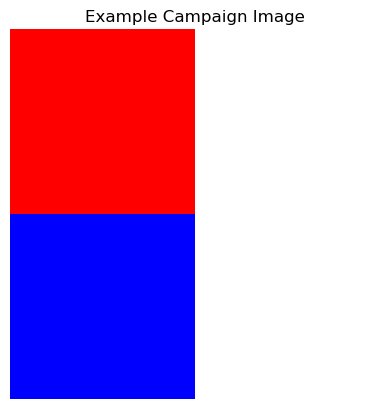

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Hypothetical image from a Veterans solicitation campaign
# Tiny 2x2 RGB image

campaign_image = np.array([
    [[255,   0,   0], [255, 255, 255]],
    [[  0,   0, 255], [255, 255, 255]]
], dtype=np.uint8)

print("Shape:", campaign_image.shape)
print(campaign_image)

plt.imshow(campaign_image)
plt.title("Example Campaign Image")
plt.axis("off")
plt.show()

---

# 17. What Does "Model-Ready" Mean?

Before modeling, you should be able to explain:

- what the target is
- which variables will be predictors
- whether variable types are correct
- how missing values were handled
- whether missing indicators were created
- how unusual observations were handled
- what transformations were used
- how categorical variables were encoded
- which variables were removed and why
- whether leakage was checked
- whether the final matrix is numeric and suitable for the intended model

## Practice 17A — Build the preparation recipe

Complete the table.

| EDA finding | Your decision |
|---|---|
| `$` stored in numeric fields |  |
| `DemCluster` coded numerically |  |
| Missing `DemMedIncome` |  |
| Missing categorical value |  |
| Age = 160 |  |
| Very large but plausible donation |  |
| Strong right skew in gift variables |  |
| 54-level `DemCluster` |  |
| `ID` |  |
| `TARGET_D` when predicting `TARGET_B` |  |

---

# 18. Save Your Progress

One of the habits in the previous notebooks was saving a cleaned intermediate dataset so later modules could start from the prepared file.

In [ ]:
# Example once you finish your decisions:
modeling_df.to_csv("data/vet_data_clean.csv", index=False)

---

# 19. Final Challenge — Explain Your Cleaning Plan

Write a short analyst memo (5–7 sentences) explaining:

1. the target you intend to model
2. the most important EDA problems you found
3. how you handled missing data
4. how you handled unusual observations
5. how you handled skewness
6. how you encoded categorical variables
7. which variables you excluded and why

**Your memo:**  
-

## Exit Ticket

Which preparation decision in this module requires the **most business/domain judgment**, rather than simply knowing Python syntax?

**Your response here:**  
-